# DOGE Analysis — Natural Experiment Design

Three-period structure:
- **Pre-DOGE**: Jan–Dec 2024 (clean baseline before DOGE existed)
- **DOGE Active**: Jan–Nov 2025 (EO 14210 signed Jan 20, disbanded Nov 2025)
- **Post-DOGE**: Dec 2025–Feb 2026 (recovery window)

In [127]:
from pathlib import Path
import sys
import pickle

sys.path.append(str(Path.cwd().parent))
from scripts.data_loader import load_r2_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency, kruskal
import statsmodels.formula.api as smf

plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})

OUTPUT = Path('../output')
OUTPUT.mkdir(exist_ok=True)

## Load Data

In [128]:
# Employment — from cache
EMP_CACHE = Path('employment.pkl')
with open(EMP_CACHE, 'rb') as f:
    e_df = pickle.load(f)
e_df['ym'] = e_df['year'].astype(str) + '-' + e_df['month'].astype(str).str.zfill(2)
print(f'Employment: {e_df.shape[0]:,} rows')

Employment: 2,446,848 rows


In [129]:
SEP_AGG_COLS = [
    'agency_subelement_code', 'agency_subelement',
    'separation_category_code', 'separation_category',
    'age_bracket', 'tenure_code', 'tenure',
    'appointment_type_code', 'appointment_type',
    'pay_plan', 'work_schedule', 'education_level_bracket',
]

SEP_CACHE = Path('separations.pkl')
if SEP_CACHE.exists():
    with open(SEP_CACHE, 'rb') as f:
        s_df = pickle.load(f)
    print('Separations loaded from cache')
else:
    s_df = load_r2_data('separations', agg_cols=SEP_AGG_COLS)
    with open(SEP_CACHE, 'wb') as f:
        pickle.dump(s_df, f)
    print('Separations fetched from R2 and cached')

INVOLUNTARY = {'SH', 'SJ'}
s_df['sep_class'] = s_df['separation_category_code'].apply(
    lambda c: 'involuntary' if c in INVOLUNTARY else ('voluntary' if c in {'SC','SD','SE','SG','SA','SB'} else 'other')
)
s_df['ym'] = s_df['year'].astype(str) + '-' + s_df['month'].astype(str).str.zfill(2)
print(f'Separations: {s_df.shape[0]:,} rows')

Separations loaded from cache
Separations: 296,052 rows


In [130]:
# Period labels
def assign_period(ym):
    if ym <= '2024-12':
        return 'Pre-DOGE'
    elif ym <= '2025-11':
        return 'DOGE Active'
    else:
        return 'Post-DOGE'

PERIOD_ORDER = ['Pre-DOGE', 'DOGE Active', 'Post-DOGE']

e_df['period'] = e_df['ym'].apply(assign_period)
s_df['period'] = s_df['ym'].apply(assign_period)

print('Employment period counts:')
print(e_df.groupby('period')['count'].sum().reindex(PERIOD_ORDER))
print('\nSeparation period counts:')
print(s_df.groupby('period')['count'].sum().reindex(PERIOD_ORDER))

Employment period counts:
period
Pre-DOGE       27555341
DOGE Active    24449976
Post-DOGE       6138131
Name: count, dtype: int64

Separation period counts:
period
Pre-DOGE       225004
DOGE Active    328216
Post-DOGE       89623
Name: count, dtype: int64


## Descriptive Overview: Three-Period Comparison
Baseline involuntary separation rates, headcount, and involuntary totals across all three periods.

In [131]:
# Monthly involuntary rate: total inv seps / total headcount per month
total_headcount = e_df.groupby('ym')['count'].sum().rename('headcount')
total_inv = (
    s_df[s_df['sep_class'] == 'involuntary']
    .groupby('ym')['count'].sum().rename('inv_seps')
)
monthly = pd.concat([total_headcount, total_inv], axis=1).fillna(0).reset_index()
monthly['inv_rate_pct'] = (monthly['inv_seps'] / monthly['headcount'] * 100).round(4)
monthly['period'] = monthly['ym'].apply(assign_period)
monthly = monthly.sort_values('ym')

# Period summary
period_summary = (
    monthly.groupby('period')
    .agg(
        months=('ym', 'count'),
        avg_headcount=('headcount', 'mean'),
        total_inv_seps=('inv_seps', 'sum'),
        avg_monthly_inv_rate=('inv_rate_pct', 'mean'),
        max_monthly_inv_rate=('inv_rate_pct', 'max'),
    )
    .reindex(PERIOD_ORDER)
    .round(3)
)
period_summary

,months,avg_headcount,total_inv_seps,avg_monthly_inv_rate,max_monthly_inv_rate
period,,,,,
Pre-DOGE,12,2296278.417,31888,0.115,0.214
DOGE Active,11,2222725.091,43881,0.180,0.371
Post-DOGE,3,2046043.667,8122,0.132,0.185


## Interrupted Time Series (ITS)
Segmented regression models the monthly involuntary separation rate as a function of time trend, a level/slope change at DOGE onset (Jan 2025), and a level/slope change at DOGE disbandment (Dec 2025).

Model: `inv_rate ~ t + doge_level + t_doge + post_level + t_post`
- `t`: pre-existing monthly trend
- `doge_level`: immediate level shift at DOGE onset
- `t_doge`: slope change after DOGE onset
- `post_level`: immediate level shift at post-DOGE
- `t_post`: slope change after post-DOGE

In [132]:
its = monthly.copy().sort_values('ym').reset_index(drop=True)
its['t'] = range(len(its))

t_doge = its[its['ym'] == '2025-01'].index[0]
t_post = its[its['ym'] == '2025-12'].index[0]

its['doge_level'] = (its['t'] >= t_doge).astype(int)
its['t_doge']     = (its['t'] - t_doge).clip(lower=0) * its['doge_level']
its['post_level'] = (its['t'] >= t_post).astype(int)
its['t_post']     = (its['t'] - t_post).clip(lower=0) * its['post_level']

model_its = smf.ols(
    'inv_rate_pct ~ t + doge_level + t_doge + post_level + t_post',
    data=its
).fit()
print(model_its.summary())

                            OLS Regression Results                            
Dep. Variable:           inv_rate_pct   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     3.190
Date:                Sun, 19 Apr 2026   Prob (F-statistic):             0.0281
Time:                        13:15:46   Log-Likelihood:                 38.752
No. Observations:                  26   AIC:                            -65.50
Df Residuals:                      20   BIC:                            -57.95
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0578      0.034      1.714      0.1

In [133]:
# ITS coefficients table
its_coef = pd.DataFrame({
    'coef': model_its.params,
    'ci_low': model_its.conf_int()[0],
    'ci_high': model_its.conf_int()[1],
    'p_value': model_its.pvalues
}).round(5)
its_coef

,coef,ci_low,ci_high,p_value
Intercept,0.05783,-0.01257,0.12823,0.10207
t,0.01047,-0.00037,0.02131,0.05762
doge_level,-0.07213,-0.18036,0.03610,0.17976
t_doge,0.00331,-0.01313,0.01975,0.67907
post_level,-0.11615,-0.26119,0.02888,0.11037
t_post,-0.02818,-0.12068,0.06432,0.53235


## Three-Period Kruskal-Wallis Test
Non-parametric test comparing monthly involuntary separation rates across the three periods. Kruskal-Wallis is preferred over ANOVA here because rates are right-skewed. Significant result = the distribution of monthly rates differs across at least one period pair.

In [134]:
pre   = monthly[monthly['period'] == 'Pre-DOGE']['inv_rate_pct']
doge  = monthly[monthly['period'] == 'DOGE Active']['inv_rate_pct']
post  = monthly[monthly['period'] == 'Post-DOGE']['inv_rate_pct']

stat, p = kruskal(pre, doge, post)
print(f'Kruskal-Wallis H = {stat:.4f}, p = {p:.6f}')
print()
print('Mean monthly involuntary rate by period:')
for label, series in [('Pre-DOGE', pre), ('DOGE Active', doge), ('Post-DOGE', post)]:
    print(f'  {label}: {series.mean():.4f}% (median {series.median():.4f}%)')

Kruskal-Wallis H = 4.0443, p = 0.132371

Mean monthly involuntary rate by period:
  Pre-DOGE: 0.1154% (median 0.1033%)
  DOGE Active: 0.1802% (median 0.1595%)
  Post-DOGE: 0.1323% (median 0.1204%)


In [135]:
# Pairwise Mann-Whitney U tests
from scipy.stats import mannwhitneyu

pairs = [
    ('Pre-DOGE', 'DOGE Active', pre, doge),
    ('Pre-DOGE', 'Post-DOGE',  pre, post),
    ('DOGE Active', 'Post-DOGE', doge, post),
]
results = []
for a_label, b_label, a, b in pairs:
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    results.append({'comparison': f'{a_label} vs {b_label}', 'U_stat': round(stat, 2), 'p_value': round(p, 6)})
pd.DataFrame(results)

,comparison,U_stat,p_value
0,Pre-DOGE vs DOGE Active,34.0,0.052539
1,Pre-DOGE vs Post-DOGE,14.0,0.632967
2,DOGE Active vs Post-DOGE,22.0,0.456044


## Demographic Disparity Analysis with Chi-Square Tests
For each demographic dimension, compare the distribution of workers in the pre-DOGE workforce to the distribution of DOGE-period involuntary separations. A chi-square test formally tests whether those distributions are equal (H₀: no disparity).

In [136]:
def disparity_with_chi2(col):
    """Disparity table + chi-square test for a demographic column."""
    # Pre-DOGE baseline (2024)
    workforce = (
        e_df[e_df['period'] == 'Pre-DOGE']
        .groupby(col)['count'].sum()
    )
    # DOGE-period involuntary seps
    inv_seps = (
        s_df[(s_df['sep_class'] == 'involuntary') & (s_df['period'] == 'DOGE Active')]
        .groupby(col)['count'].sum()
    )
    # Align on common categories
    common = workforce.index.intersection(inv_seps.index)
    wf = workforce[common]
    inv = inv_seps[common]

    # Chi-square on raw counts
    contingency = pd.DataFrame({'workforce': wf, 'inv_seps': inv}).dropna()
    chi2, p, dof, _ = chi2_contingency(contingency.T)

    # Percentage table
    result = pd.DataFrame({
        'workforce_pct': (wf / wf.sum() * 100).round(1),
        'inv_sep_pct':   (inv / inv.sum() * 100).round(1),
    }).dropna()
    result['overrepresentation'] = (result['inv_sep_pct'] - result['workforce_pct']).round(1)
    result = result.sort_values('overrepresentation', ascending=False)

    print(f'Chi-square({dof}) = {chi2:.2f}, p = {p:.2e}')
    return result

In [137]:
print('=== Age Bracket ===')
age_disp = disparity_with_chi2('age_bracket')
age_disp

=== Age Bracket ===
Chi-square(10) = 30571.58, p = 0.00e+00


,workforce_pct,inv_sep_pct,overrepresentation
age_bracket,,,
20-24,2.5,12.6,10.1
25-29,6.2,14.2,8.0
65 OR MORE,5.6,9.0,3.4
30-34,9.3,12.1,2.8
LESS THAN 20,0.1,1.1,1.0
35-39,12.5,10.7,-1.8
40-44,14.6,11.0,-3.6
45-49,13.3,9.6,-3.7
60-64,9.5,5.3,-4.2


In [138]:
print('=== Tenure ===')
tenure_disp = disparity_with_chi2('tenure')
tenure_disp

=== Tenure ===
Chi-square(4) = 358225.60, p = 0.00e+00


,workforce_pct,inv_sep_pct,overrepresentation
tenure,,,
"NO TENURE GROUP - EMPLOYEES (E.G., TEMPORARIES OR SES) NOT IN TENURE GROUPS 1, 2, OR 3 FOR RIF PURPOSES",2.9,49.6,46.7
TENURE GROUP 3 - TAPER/TERM OR PROVISIONAL OR APPTS W/OUT TIME LIMIT BUT NOT ACTUALLY OR POTENTIALLY PERMANENT,3.8,16.7,12.9
INVALID,0.0,0.0,0.0
TENURE GROUP 2 - CAREER-CONDITIONAL OR OTHER APPT THAT IS CONDITIONAL OR REQUIRES PROBATIONARY OR TRIAL PERIOD,18.3,12.7,-5.6
TENURE GROUP 1 - CAREER OR SERVING AN APPOINTMENT CARRYING NO RESTRICTION OR CONDITION,75.1,21.0,-54.1


In [139]:
print('=== Appointment Type ===')
appt_disp = disparity_with_chi2('appointment_type')
appt_disp

=== Appointment Type ===
Chi-square(16) = 279455.55, p = 0.00e+00


,workforce_pct,inv_sep_pct,overrepresentation
appointment_type,,,
OTHER (EXCEPTED SERVICE NONPERMANENT),3.0,29.9,26.9
NONPERMANENT (COMPETITTIVE SERVICE NONPERMANENT),1.7,23.1,21.4
SCHEDULE A (EXCEPTED SERVICE NONPERMANENT),1.2,11.4,10.2
SCHEDULE D (EXCEPTED SERVICE NONPERMANENT),0.1,1.2,1.1
SCHEDULE D (EXCEPTED SERVICE PERMANENT),0.3,1.2,0.9
SCHEDULE A (EXCEPTED SERVICE PERMANENT),3.2,3.7,0.5
EXECUTIVE (EXCEPTED SERVICE NONPERMANENT),0.0,0.2,0.2
SCHEDULE B (EXCEPTED SERVICE NONPERMANENT),0.1,0.3,0.2
INVALID,0.0,0.1,0.1


In [140]:
print('=== Work Schedule ===')
schedule_disp = disparity_with_chi2('work_schedule')
schedule_disp

=== Work Schedule ===
Chi-square(6) = 87154.70, p = 0.00e+00


,workforce_pct,inv_sep_pct,overrepresentation
work_schedule,,,
INTERMITTENT,1.7,19.6,17.9
PART-TIME,1.9,3.6,1.7
INTERMITTENT SEASONAL,0.2,1.3,1.1
PART-TIME SEASONAL,0.1,0.2,0.1
FULL-TIME SEASONAL,1.2,1.2,0.0
PART-TIME JOB SHARER,0.0,0.0,0.0
FULL-TIME,94.9,74.2,-20.7


In [141]:
print('=== Education Level ===')
edu_disp = disparity_with_chi2('education_level_bracket')
edu_disp

=== Education Level ===
Chi-square(5) = 29485.48, p = 0.00e+00


,workforce_pct,inv_sep_pct,overrepresentation
education_level_bracket,,,
HIGH SCHOOL OR LESS,28.8,35.8,7.0
DOCTORATE DEGREE,4.2,8.4,4.2
NO DATA REPORTED,0.2,3.3,3.1
MASTERS OR PROFESSIONAL DEGREE,21.6,23.9,2.3
SOME COLLEGE OR ASSOCIATES DEGREE,17.6,9.6,-8.0
BACHELORS DEGREE,27.6,19.0,-8.6


## Retention Rate by Demographic Group
For each demographic category, compute the average monthly headcount in each period relative to the 2024 baseline. Retention % = period average / 2024 average × 100.

In [142]:
def retention_by_group(col):
    """Retention rate across three periods relative to 2024 baseline."""
    pivot = (
        e_df.groupby([col, 'ym', 'period'])['count']
        .sum()
        .reset_index()
        .groupby([col, 'period'])['count']
        .mean()  # avg monthly headcount per period
        .unstack('period')
        .reindex(columns=PERIOD_ORDER)
    )
    baseline = pivot['Pre-DOGE']
    for period in PERIOD_ORDER:
        pivot[f'{period} retention %'] = (pivot[period] / baseline * 100).round(1)
    return pivot[[f'{p} retention %' for p in PERIOD_ORDER]].sort_values('DOGE Active retention %')

In [143]:
print('=== Retention by Age Bracket ===')
retention_by_group('age_bracket')

=== Retention by Age Bracket ===


period,Pre-DOGE retention %,DOGE Active retention %,Post-DOGE retention %
age_bracket,,,
LESS THAN 20,100.0,51.4,25.2
20-24,100.0,89.1,70.1
30-34,100.0,95.1,86.5
35-39,100.0,95.1,87.7
25-29,100.0,95.2,84.4
50-54,100.0,95.5,88.3
55-59,100.0,96.2,88.7
60-64,100.0,97.3,86.4
65 OR MORE,100.0,97.8,85.0


In [144]:
print('=== Retention by Tenure ===')
retention_by_group('tenure')

=== Retention by Tenure ===


period,Pre-DOGE retention %,DOGE Active retention %,Post-DOGE retention %
tenure,,,
INVALID,100.0,23.0,23.8
"NO TENURE GROUP - EMPLOYEES (E.G., TEMPORARIES OR SES) NOT IN TENURE GROUPS 1, 2, OR 3 FOR RIF PURPOSES",100.0,81.1,65.8
TENURE GROUP 2 - CAREER-CONDITIONAL OR OTHER APPT THAT IS CONDITIONAL OR REQUIRES PROBATIONARY OR TRIAL PERIOD,100.0,84.2,64.9
TENURE GROUP 3 - TAPER/TERM OR PROVISIONAL OR APPTS W/OUT TIME LIMIT BUT NOT ACTUALLY OR POTENTIALLY PERMANENT,100.0,89.9,78.3
TENURE GROUP 1 - CAREER OR SERVING AN APPOINTMENT CARRYING NO RESTRICTION OR CONDITION,100.0,100.8,96.4
NO DATA REPORTED,NaN,NaN,NaN


In [145]:
print('=== Retention by Education ===')
retention_by_group('education_level_bracket')

=== Retention by Education ===


period,Pre-DOGE retention %,DOGE Active retention %,Post-DOGE retention %
education_level_bracket,,,
NO DATA REPORTED,100.0,94.3,91.6
SOME COLLEGE OR ASSOCIATES DEGREE,100.0,94.8,87.5
BACHELORS DEGREE,100.0,96.9,89.4
HIGH SCHOOL OR LESS,100.0,97.3,89.2
MASTERS OR PROFESSIONAL DEGREE,100.0,97.4,89.5
DOCTORATE DEGREE,100.0,97.8,90.3


## Agency Fixed-Effects Panel Regression
Panel model: agency × month observations with agency fixed effects (within transformation). Tests whether the DOGE active and post-DOGE periods predict higher involuntary separation rates controlling for time-invariant agency characteristics.

In [146]:
# Build agency × month rate panel
emp_am = (
    e_df.groupby(['ym', 'agency_subelement_code'])['count']
    .sum().reset_index().rename(columns={'count': 'headcount'})
)
inv_am = (
    s_df[s_df['sep_class'] == 'involuntary']
    .groupby(['ym', 'agency_subelement_code'])['count']
    .sum().reset_index().rename(columns={'count': 'inv_seps'})
)
panel = emp_am.merge(inv_am, on=['ym', 'agency_subelement_code'], how='left')
panel['inv_seps'] = panel['inv_seps'].fillna(0)
panel['inv_rate_pct'] = (panel['inv_seps'] / panel['headcount'] * 100).round(4)
panel['period'] = panel['ym'].apply(assign_period)
panel['doge_active'] = (panel['period'] == 'DOGE Active').astype(int)
panel['post_doge']   = (panel['period'] == 'Post-DOGE').astype(int)

# Within transformation: demean by agency (absorbs agency fixed effects)
panel['rate_demeaned'] = (
    panel['inv_rate_pct']
    - panel.groupby('agency_subelement_code')['inv_rate_pct'].transform('mean')
)

model_fe = smf.ols('rate_demeaned ~ doge_active + post_doge', data=panel).fit(
    cov_type='HC3'  # heteroskedasticity-robust standard errors
)
print(model_fe.summary())

                            OLS Regression Results                            
Dep. Variable:          rate_demeaned   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     7.766
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           0.000426
Time:                        13:15:48   Log-Likelihood:                -51124.
No. Observations:               13723   AIC:                         1.023e+05
Df Residuals:                   13720   BIC:                         1.023e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.2726      0.036     -7.627      

## Improved Models

Four upgrades over the baseline:
1. **Panel ITS** — agency × month panel (n ≈ 13k) with agency FE + month-of-year FE, far more power than 26-obs national aggregate
2. **Event study** — distributed lags instead of a single dummy; tests pre-trends and shows how effects evolved month-by-month
3. **Two-way FE** — agency + calendar-month FE with SEs clustered by agency
4. **Negative binomial ITS** — replaces OLS on rates with a count model on raw seps; handles right-skew and overdispersion

All panel models use `linearmodels.PanelOLS` with `cov_type='clustered', cluster_entity=True`.

### Model 1: Panel ITS (Agency FE + Month-of-Year Controls)

Run the interrupted time series at the agency × month level (n ≈ 13k) instead of the 26-point national aggregate. Agency fixed effects absorb time-invariant agency characteristics; month-of-year dummies (Feb–Dec, Jan = baseline) absorb seasonal hiring/firing cycles. Standard errors clustered by agency.

In [147]:
from linearmodels import PanelOLS

panel_its = panel.copy()
panel_its['date'] = pd.to_datetime(panel_its['ym'] + '-01')

ym_order = sorted(panel_its['ym'].unique())
t_map = {ym: i for i, ym in enumerate(ym_order)}
panel_its['t'] = panel_its['ym'].map(t_map)
panel_its['month_num'] = panel_its['date'].dt.month

t_doge_idx = t_map['2025-01']
t_post_idx  = t_map['2025-12']

panel_its['doge_level'] = (panel_its['t'] >= t_doge_idx).astype(float)
panel_its['t_doge']     = (panel_its['t'] - t_doge_idx).clip(lower=0).astype(float)
panel_its['post_level'] = (panel_its['t'] >= t_post_idx).astype(float)
panel_its['t_post']     = (panel_its['t'] - t_post_idx).clip(lower=0).astype(float)

# Month-of-year dummies for seasonality (Jan = baseline, drop m1)
month_dummies = pd.get_dummies(
    panel_its['month_num'].astype(str).radd('m'), drop_first=False
).astype(float).drop(columns=['m1'])
month_cols = list(month_dummies.columns)
panel_its = pd.concat([panel_its, month_dummies], axis=1)

# linearmodels requires time index to be numeric or datetime
panel_its = panel_its.set_index(['agency_subelement_code', 'date'])
exog_panel_its = panel_its[['t', 'doge_level', 't_doge', 'post_level', 't_post'] + month_cols]

model_panel_its = PanelOLS(
    panel_its['inv_rate_pct'],
    exog_panel_its,
    entity_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

print(model_panel_its.summary)

panel_its_coef = pd.DataFrame({
    'coef':    model_panel_its.params,
    'ci_low':  model_panel_its.conf_int()['lower'],
    'ci_high': model_panel_its.conf_int()['upper'],
    'p_value': model_panel_its.pvalues,
}).loc[['t', 'doge_level', 't_doge', 'post_level', 't_post']].round(5)
panel_its_coef

                          PanelOLS Estimation Summary                           
Dep. Variable:           inv_rate_pct   R-squared:                        0.0033
Estimator:                   PanelOLS   R-squared (Between):              0.0154
No. Observations:               13723   R-squared (Within):               0.0033
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.0044
Time:                        13:15:48   Log-likelihood                -5.111e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.7024
Entities:                         558   P-value                           0.0003
Avg Obs:                       24.593   Distribution:                F(16,13149)
Min Obs:                       1.0000                                           
Max Obs:                       26.000   F-statistic (robust):             2.8916
                            

,coef,ci_low,ci_high,p_value
t,0.07540,-0.01854,0.16933,0.11566
doge_level,-0.76725,-1.90038,0.36588,0.18446
t_doge,0.09020,-0.01165,0.19204,0.08259
post_level,-1.07952,-1.95372,-0.20531,0.01551
t_post,-0.37201,-0.94700,0.20298,0.20475


### Model 2: Event Study (Distributed Lags)

Replace the single `doge_active` binary with month-relative-to-onset indicators (t−12 through t+11, reference = t−1 = Dec 2024). This reveals whether effects built over time, peaked, or faded — and the pre-period coefficients (t−12 through t−2) serve as a falsification test: if they're near zero, the parallel trends assumption holds.

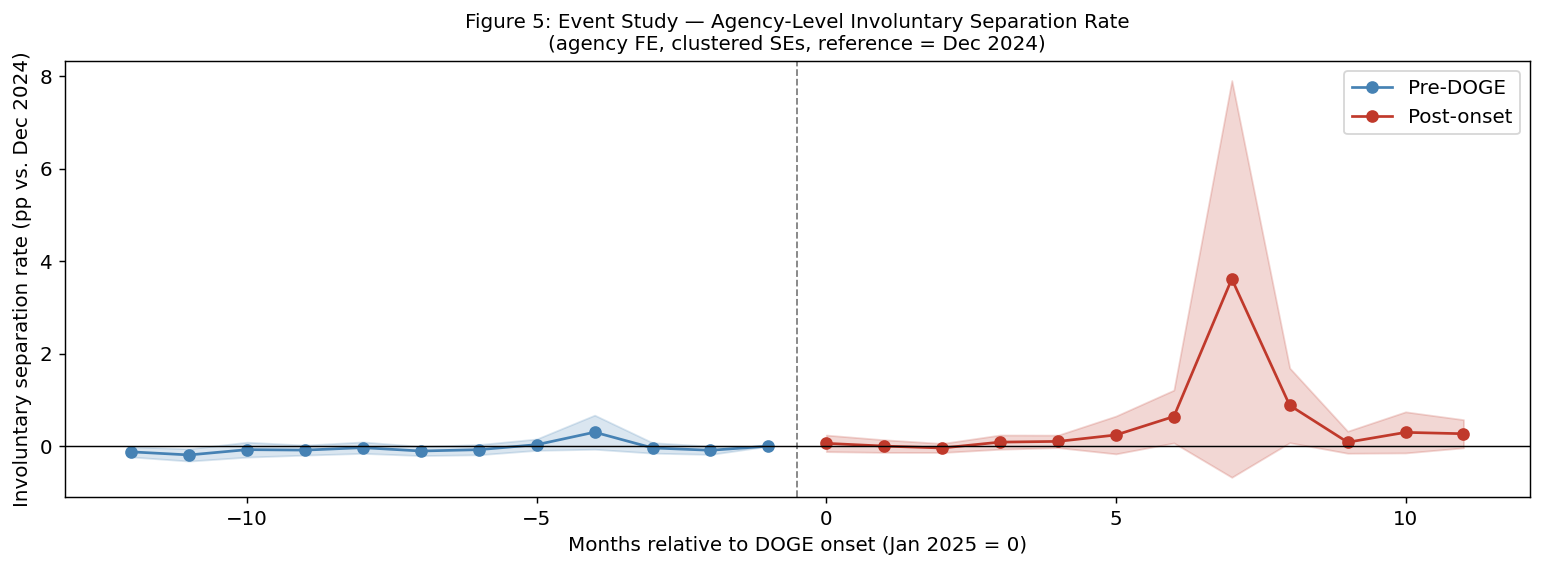

                          PanelOLS Estimation Summary                           
Dep. Variable:           inv_rate_pct   R-squared:                        0.0050
Estimator:                   PanelOLS   R-squared (Between):              0.0121
No. Observations:               13723   R-squared (Within):               0.0050
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.0059
Time:                        13:15:48   Log-likelihood                -5.109e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.8920
Entities:                         558   P-value                           0.0000
Avg Obs:                       24.593   Distribution:                F(23,13142)
Min Obs:                       1.0000                                           
Max Obs:                       26.000   F-statistic (robust):             3.7794
                            

In [148]:
def months_rel(ym, ref='2025-01'):
    ry, rm = map(int, ref.split('-'))
    y, m = map(int, ym.split('-'))
    return (y - ry) * 12 + (m - rm)

panel_es = panel.copy()
panel_es['date'] = pd.to_datetime(panel_es['ym'] + '-01')
panel_es['t_rel'] = panel_es['ym'].apply(months_rel).clip(-12, 11)

# Dummies for each relative period; reference = -1 (Dec 2024)
es_dummies = pd.get_dummies(panel_es['t_rel'], prefix='rel').astype(float)
ref_col = 'rel_-1'
if ref_col in es_dummies.columns:
    es_dummies = es_dummies.drop(columns=[ref_col])
es_cols = sorted(es_dummies.columns, key=lambda c: int(c.split('_')[1]))

panel_es = pd.concat([panel_es, es_dummies], axis=1)
panel_es = panel_es.set_index(['agency_subelement_code', 'date'])

model_es = PanelOLS(
    panel_es['inv_rate_pct'],
    panel_es[es_cols],
    entity_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# Build plot dataframe including the omitted reference period at 0
es_plot = pd.DataFrame({
    'coef':    model_es.params,
    'ci_low':  model_es.conf_int()['lower'],
    'ci_high': model_es.conf_int()['upper'],
}, index=es_cols)
es_plot['t'] = [int(c.split('_')[1]) for c in es_plot.index]
ref_row = pd.DataFrame({'coef': 0, 'ci_low': 0, 'ci_high': 0, 't': -1}, index=['ref'])
es_plot = pd.concat([es_plot, ref_row]).sort_values('t')

fig, ax = plt.subplots(figsize=(12, 4.5))
pre  = es_plot[es_plot['t'] < 0]
post = es_plot[es_plot['t'] >= 0]

ax.fill_between(pre['t'],  pre['ci_low'],  pre['ci_high'],  alpha=0.2, color='steelblue')
ax.fill_between(post['t'], post['ci_low'], post['ci_high'], alpha=0.2, color='#c0392b')
ax.plot(pre['t'],  pre['coef'],  'o-', color='steelblue', label='Pre-DOGE')
ax.plot(post['t'], post['coef'], 'o-', color='#c0392b',   label='Post-onset')
ax.axvline(-0.5, color='gray', linestyle='--', linewidth=1)
ax.axhline(0,    color='black', linewidth=0.8)
ax.set_xlabel('Months relative to DOGE onset (Jan 2025 = 0)')
ax.set_ylabel('Involuntary separation rate (pp vs. Dec 2024)')
ax.set_title('Figure 5: Event Study — Agency-Level Involuntary Separation Rate\n(agency FE, clustered SEs, reference = Dec 2024)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT / 'fig5_event_study.png', bbox_inches='tight')
plt.show()

print(model_es.summary)

### Model 3: Agency FE + Agency-Specific Linear Trends (Frisch-Waugh)

The two-way FE spec (entity + calendar-month FE) is not identified here: `doge_active` and `post_doge` are constant within each calendar month, so the time FE absorbs them exactly — causing the numerical blowup in the previous version.

The correct stricter alternative is **agency-specific linear time trends**: each agency gets its own intercept *and* its own slope, giving it a bespoke counterfactual trajectory. Treatment effects are identified only from deviations above or below each agency's own projected trend line.

Estimated via Frisch-Waugh partial-out:
1. Within each agency, regress `inv_rate_pct`, `doge_active`, and `post_doge` on `[1, t]` and keep the residuals
2. Regress the outcome residuals on the treatment residuals with SEs clustered by agency

This absorbs both agency fixed effects and agency-specific trends in one step.

In [149]:
panel_agt = panel.copy()
panel_agt['t'] = panel_agt['ym'].map(t_map)  # t_map defined in Model 1

def partial_out_trend(group):
    """Remove agency intercept + agency-specific linear trend from each variable."""
    t = group['t'].values
    X = np.column_stack([np.ones(len(t)), t])
    out = {}
    for col in ['inv_rate_pct', 'doge_active', 'post_doge']:
        y = group[col].values
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        out[col + '_r'] = y - X @ beta
    return pd.DataFrame(out, index=group.index)

resids = panel_agt.groupby('agency_subelement_code', group_keys=False).apply(partial_out_trend)
panel_agt = panel_agt.join(resids)

# Regress detrended outcome on detrended treatment vars, clustered SEs, no intercept
model_agt = smf.ols(
    'inv_rate_pct_r ~ doge_active_r + post_doge_r - 1',
    data=panel_agt
).fit(cov_type='cluster', cov_kwds={'groups': panel_agt['agency_subelement_code']})

print(model_agt.summary())

agt_coef = pd.DataFrame({
    'coef':    model_agt.params,
    'ci_low':  model_agt.conf_int()[0],
    'ci_high': model_agt.conf_int()[1],
    'p_value': model_agt.pvalues,
}).round(5)
agt_coef

                                 OLS Regression Results                                
Dep. Variable:         inv_rate_pct_r   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                              3.708
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                      0.0251
Time:                        13:15:49   Log-Likelihood:                         -50371.
No. Observations:               13723   AIC:                                  1.007e+05
Df Residuals:                   13721   BIC:                                  1.008e+05
Df Model:                           2                                                  
Covariance Type:              cluster                                                  
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

,coef,ci_low,ci_high,p_value
doge_active_r,-0.09654,-0.30338,0.11031,0.36034
post_doge_r,-0.50160,-0.89104,-0.11216,0.01159


### Model 4: Negative Binomial ITS (Count Model)

Replace OLS on rates with a negative binomial regression on raw involuntary separation counts, using log(headcount) as an exposure offset. This is the correct distributional choice for count data that is right-skewed and overdispersed (variance >> mean), which is what the OLS residual diagnostics flagged (kurtosis ~5.4 in the aggregate model).

The NegBin ITS uses the same 26 monthly national-aggregate observations as the original OLS ITS — a direct apples-to-apples comparison.

In [150]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

its_nb = its.copy()
its_nb['inv_seps'] = its_nb['inv_seps'].astype(int)

endog_nb = its_nb['inv_seps']
exog_nb  = sm.add_constant(its_nb[['t', 'doge_level', 't_doge', 'post_level', 't_post']])

model_nb = NegativeBinomial(endog_nb, exog_nb, exposure=its_nb['headcount']).fit(disp=False)
print(model_nb.summary())

nb_coef = pd.DataFrame({
    'coef':    model_nb.params,
    'ci_low':  model_nb.conf_int()[0],
    'ci_high': model_nb.conf_int()[1],
    'p_value': model_nb.pvalues,
}).round(5)
nb_coef

                     NegativeBinomial Regression Results                      
Dep. Variable:               inv_seps   No. Observations:                   26
Model:               NegativeBinomial   Df Residuals:                       20
Method:                           MLE   Df Model:                            5
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.04730
Time:                        13:15:49   Log-Likelihood:                -215.34
converged:                       True   LL-Null:                       -226.03
Covariance Type:            nonrobust   LLR p-value:                 0.0006859
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.4367      0.188    -39.468      0.000      -7.806      -7.067
t              0.1111      0.030      3.754      0.000       0.053       0.169
doge_level    -0.7431      0.294     -2.524      0.0

,coef,ci_low,ci_high,p_value
const,-7.43666,-7.80596,-7.06735,0.00000
t,0.11107,0.05308,0.16905,0.00017
doge_level,-0.74312,-1.32012,-0.16611,0.01160
t_doge,-0.01296,-0.10307,0.07714,0.77794
post_level,-0.72808,-1.50642,0.05027,0.06675
t_post,-0.23463,-0.74847,0.27921,0.37081
alpha,0.10737,0.04986,0.16489,0.00025


## Voluntary Separations Analysis

Involuntary separations capture explicit firings/removals. But if workers resigned under pressure, anticipating layoffs, or in response to hostile conditions ("chilling effect"), that signal appears in *voluntary* separations instead. Comparing the two series tests whether the total attrition effect is larger than the involuntary count alone suggests.

Voluntary codes: SA (resignation), SB (retirement), SC (transfers out), SD (death/disability), SE (expiration of appointment), SG (other voluntary).

In [151]:
# Monthly voluntary and total separation rates
total_vol = (
    s_df[s_df['sep_class'] == 'voluntary']
    .groupby('ym')['count'].sum().rename('vol_seps')
)
total_all = s_df.groupby('ym')['count'].sum().rename('all_seps')

monthly_full = (
    pd.concat([total_headcount, total_inv, total_vol, total_all], axis=1)
    .fillna(0).reset_index().sort_values('ym')
)
monthly_full['inv_rate_pct'] = (monthly_full['inv_seps'] / monthly_full['headcount'] * 100).round(4)
monthly_full['vol_rate_pct'] = (monthly_full['vol_seps'] / monthly_full['headcount'] * 100).round(4)
monthly_full['total_rate_pct'] = (monthly_full['all_seps'] / monthly_full['headcount'] * 100).round(4)
monthly_full['period'] = monthly_full['ym'].apply(assign_period)

# Period summary
vol_summary = (
    monthly_full.groupby('period')
    .agg(
        avg_inv_rate=('inv_rate_pct', 'mean'),
        avg_vol_rate=('vol_rate_pct', 'mean'),
        avg_total_rate=('total_rate_pct', 'mean'),
        total_vol_seps=('vol_seps', 'sum'),
        total_inv_seps=('inv_seps', 'sum'),
    )
    .reindex(PERIOD_ORDER).round(3)
)
vol_summary

,avg_inv_rate,avg_vol_rate,avg_total_rate,total_vol_seps,total_inv_seps
period,,,,,
Pre-DOGE,0.115,0.640,0.816,176448,31888
DOGE Active,0.180,1.105,1.347,269260,43881
Post-DOGE,0.132,1.265,1.459,77724,8122


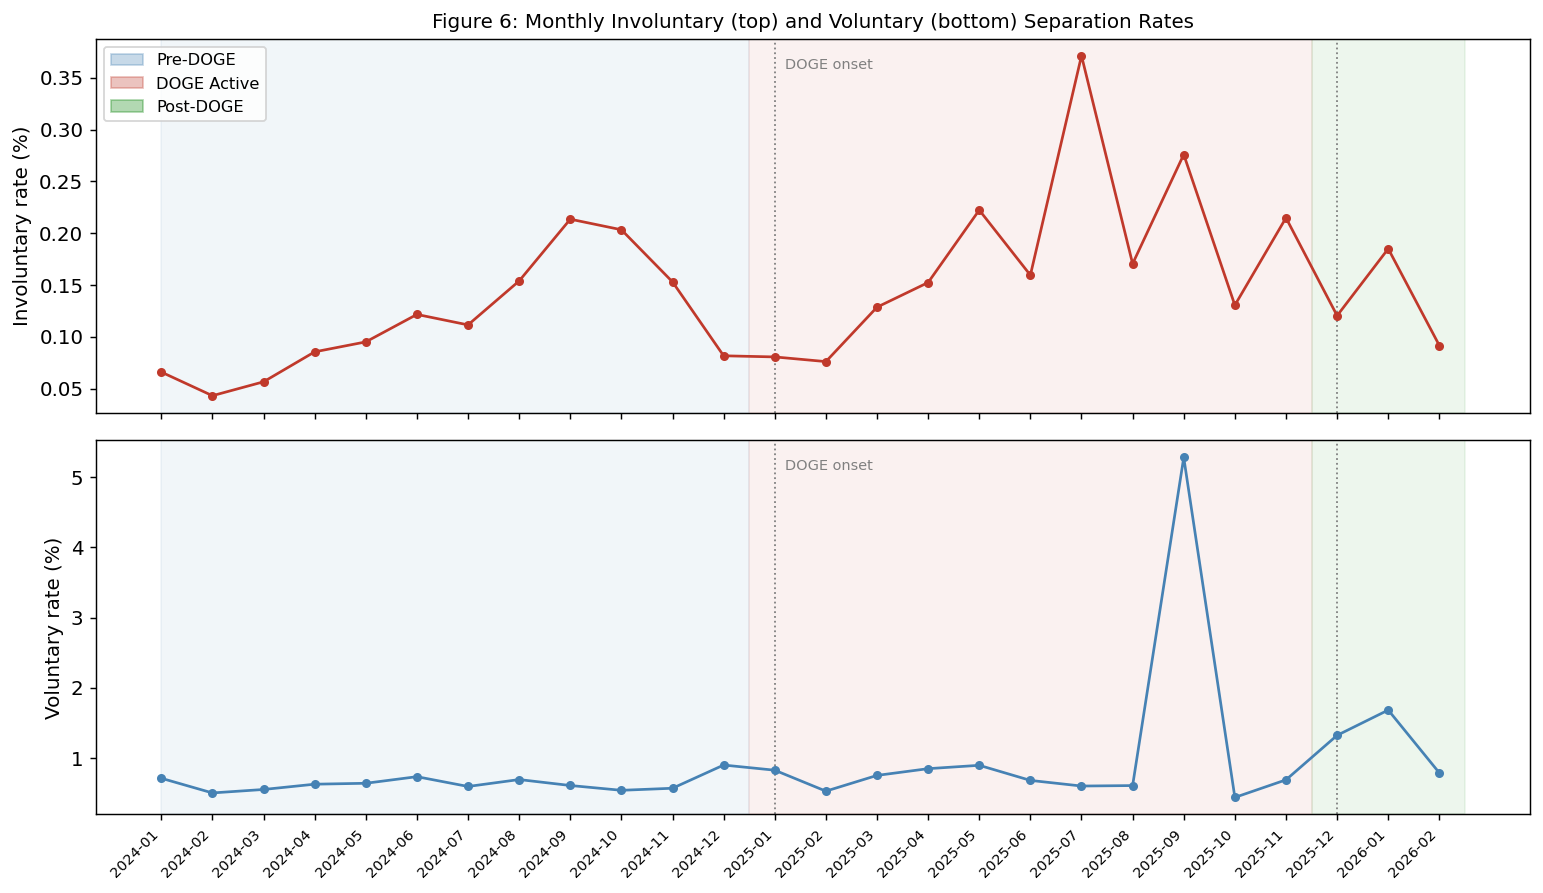

Voluntary  KW: H = 6.0215, p = 0.049255
Involuntary KW: H = 4.0443, p = 0.132371

Mean monthly rates by period:
  Pre-DOGE: inv=0.1154%  vol=0.6402%
  DOGE Active: inv=0.1802%  vol=1.1052%
  Post-DOGE: inv=0.1323%  vol=1.2653%


In [152]:
# Figure 6: Voluntary vs Involuntary separation rates side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
x = range(len(monthly_full))
ym_labels = monthly_full['ym'].tolist()

t_doge_x = ym_labels.index('2025-01')
t_post_x  = ym_labels.index('2025-12')

for ax in axes:
    ax.axvspan(0,               t_doge_x - 0.5, alpha=0.07, color='steelblue')
    ax.axvspan(t_doge_x - 0.5, t_post_x - 0.5, alpha=0.07, color='#c0392b')
    ax.axvspan(t_post_x - 0.5, len(x) - 0.5,   alpha=0.07, color='green')
    ax.axvline(t_doge_x, color='gray', linestyle=':', linewidth=1)
    ax.axvline(t_post_x,  color='gray', linestyle=':', linewidth=1)

axes[0].plot(x, monthly_full['inv_rate_pct'], 'o-', color='#c0392b', linewidth=1.5, markersize=4)
axes[0].set_ylabel('Involuntary rate (%)')
axes[0].set_title('Figure 6: Monthly Involuntary (top) and Voluntary (bottom) Separation Rates', fontsize=11)

axes[1].plot(x, monthly_full['vol_rate_pct'], 'o-', color='steelblue', linewidth=1.5, markersize=4)
axes[1].set_ylabel('Voluntary rate (%)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(ym_labels, rotation=45, ha='right', fontsize=8)

for ax in axes:
    ylim = ax.get_ylim()
    ax.text(t_doge_x + 0.2, ylim[0] + (ylim[1] - ylim[0]) * 0.92, 'DOGE onset', fontsize=8, color='gray')

patches = [
    mpatches.Patch(color='steelblue', alpha=0.3, label='Pre-DOGE'),
    mpatches.Patch(color='#c0392b',   alpha=0.3, label='DOGE Active'),
    mpatches.Patch(color='green',     alpha=0.3, label='Post-DOGE'),
]
axes[0].legend(handles=patches, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT / 'fig6_vol_inv_rates.png', bbox_inches='tight')
plt.show()

# KW tests — compute fresh from monthly_full to avoid stale Series issues
def period_rates(col):
    return [monthly_full[monthly_full['period'] == p][col].values for p in PERIOD_ORDER]

inv_by_period = period_rates('inv_rate_pct')
vol_by_period = period_rates('vol_rate_pct')

stat_v, p_v = kruskal(*vol_by_period)
stat_i, p_i = kruskal(*inv_by_period)
print(f'Voluntary  KW: H = {stat_v:.4f}, p = {p_v:.6f}')
print(f'Involuntary KW: H = {stat_i:.4f}, p = {p_i:.6f}')
print()
print('Mean monthly rates by period:')
for label, iv, vv in zip(PERIOD_ORDER, inv_by_period, vol_by_period):
    print(f'  {label}: inv={iv.mean():.4f}%  vol={vv.mean():.4f}%')

### Voluntary Separation Demographic Disparity

Same chi-square framework as the involuntary analysis: compare the distribution of DOGE-period *voluntary* separations against the 2024 workforce baseline. If the same demographic groups that were involuntarily separated are *also* overrepresented in voluntary departures, it is consistent with a chilling effect — those workers self-selected out under pressure rather than waiting to be fired.

In [153]:
def disparity_voluntary(col):
    """Disparity table + chi-square for voluntary separations during DOGE active period."""
    workforce = (
        e_df[e_df['period'] == 'Pre-DOGE']
        .groupby(col)['count'].sum()
    )
    vol_seps = (
        s_df[(s_df['sep_class'] == 'voluntary') & (s_df['period'] == 'DOGE Active')]
        .groupby(col)['count'].sum()
    )
    common = workforce.index.intersection(vol_seps.index)
    wf, vs = workforce[common], vol_seps[common]
    contingency = pd.DataFrame({'workforce': wf, 'vol_seps': vs}).dropna()
    chi2, p, dof, _ = chi2_contingency(contingency.T)
    result = pd.DataFrame({
        'workforce_pct': (wf / wf.sum() * 100).round(1),
        'vol_sep_pct':   (vs / vs.sum() * 100).round(1),
    }).dropna()
    result['overrepresentation'] = (result['vol_sep_pct'] - result['workforce_pct']).round(1)
    result = result.sort_values('overrepresentation', ascending=False)
    print(f'Chi-square({dof}) = {chi2:.2f}, p = {p:.2e}')
    return result

print('=== Age Bracket (Voluntary) ===')
age_vol = disparity_voluntary('age_bracket')
print(age_vol.to_string())

print('\n=== Tenure (Voluntary) ===')
tenure_vol = disparity_voluntary('tenure')
print(tenure_vol[['workforce_pct', 'vol_sep_pct', 'overrepresentation']].to_string())

print('\n=== Appointment Type (Voluntary) ===')
appt_vol = disparity_voluntary('appointment_type')
print(appt_vol[['workforce_pct', 'vol_sep_pct', 'overrepresentation']].to_string())

print('\n=== Education Level (Voluntary) ===')
edu_vol = disparity_voluntary('education_level_bracket')
print(edu_vol.to_string())

=== Age Bracket (Voluntary) ===
Chi-square(10) = 53210.63, p = 0.00e+00
              workforce_pct  vol_sep_pct  overrepresentation
age_bracket                                                 
65 OR MORE              5.6         13.0                 7.4
60-64                   9.5         15.2                 5.7
25-29                   6.2          7.8                 1.6
20-24                   2.5          3.9                 1.4
55-59                  12.9         13.8                 0.9
LESS THAN 20            0.1          0.2                 0.1
30-34                   9.3          9.3                 0.0
35-39                  12.5          9.9                -2.6
50-54                  13.4          9.7                -3.7
40-44                  14.6          9.4                -5.2
45-49                  13.3          7.8                -5.5

=== Tenure (Voluntary) ===
Chi-square(4) = 9889.26, p = 0.00e+00
                                                                     

### Voluntary Separations — Agency-Specific Trends Panel Model

Mirror of Model 3 (agency FE + agency-specific linear trends via Frisch-Waugh) but for the voluntary separation rate. A significant `doge_active_r` here — especially if it is positive — is evidence of a chilling effect: voluntary departures were elevated *above each agency's own projected trend* during the DOGE period.

In [154]:
# Build agency × month voluntary rate panel
vol_am = (
    s_df[s_df['sep_class'] == 'voluntary']
    .groupby(['ym', 'agency_subelement_code'])['count']
    .sum().reset_index().rename(columns={'count': 'vol_seps'})
)
panel_vol = emp_am.merge(vol_am, on=['ym', 'agency_subelement_code'], how='left')
panel_vol['vol_seps'] = panel_vol['vol_seps'].fillna(0)
panel_vol['vol_rate_pct'] = (panel_vol['vol_seps'] / panel_vol['headcount'] * 100).round(4)
panel_vol['period'] = panel_vol['ym'].apply(assign_period)
panel_vol['doge_active'] = (panel_vol['period'] == 'DOGE Active').astype(int)
panel_vol['post_doge']   = (panel_vol['period'] == 'Post-DOGE').astype(int)
panel_vol['t'] = panel_vol['ym'].map(t_map)

def partial_out_trend(group):
    t = group['t'].values
    X = np.column_stack([np.ones(len(t)), t])
    out = {}
    for col in ['vol_rate_pct', 'doge_active', 'post_doge']:
        y = group[col].values
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        out[col + '_r'] = y - X @ beta
    return pd.DataFrame(out, index=group.index)

resids_vol = panel_vol.groupby('agency_subelement_code', group_keys=False).apply(partial_out_trend)
panel_vol = panel_vol.join(resids_vol)

model_vol = smf.ols(
    'vol_rate_pct_r ~ doge_active_r + post_doge_r - 1',
    data=panel_vol
).fit(cov_type='cluster', cov_kwds={'groups': panel_vol['agency_subelement_code']})

print(model_vol.summary())

vol_coef = pd.DataFrame({
    'coef':    model_vol.params,
    'ci_low':  model_vol.conf_int()[0],
    'ci_high': model_vol.conf_int()[1],
    'p_value': model_vol.pvalues,
}).round(5)
vol_coef

                                 OLS Regression Results                                
Dep. Variable:         vol_rate_pct_r   R-squared (uncentered):                   0.002
Model:                            OLS   Adj. R-squared (uncentered):              0.002
Method:                 Least Squares   F-statistic:                              3.678
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                      0.0259
Time:                        13:15:50   Log-Likelihood:                         -43125.
No. Observations:               13723   AIC:                                  8.625e+04
Df Residuals:                   13721   BIC:                                  8.627e+04
Df Model:                           2                                                  
Covariance Type:              cluster                                                  
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

,coef,ci_low,ci_high,p_value
doge_active_r,1.02772,0.25804,1.79739,0.00887
post_doge_r,1.47545,0.39425,2.55665,0.00748


### Total Attrition: Voluntary + Involuntary Combined

Summing both streams gives the total workforce exit rate. This is the most complete measure of DOGE's workforce impact — it captures both explicit firings and departures that may have been coerced or voluntary-in-name-only.

In [155]:
# Total attrition panel (inv + vol) with agency-specific trends
panel_tot = emp_am.copy()
panel_tot = panel_tot.merge(
    panel[['ym', 'agency_subelement_code', 'inv_seps']],
    on=['ym', 'agency_subelement_code'], how='left'
).merge(
    panel_vol[['ym', 'agency_subelement_code', 'vol_seps']],
    on=['ym', 'agency_subelement_code'], how='left'
)
panel_tot['inv_seps'] = panel_tot['inv_seps'].fillna(0)
panel_tot['vol_seps'] = panel_tot['vol_seps'].fillna(0)
panel_tot['total_seps'] = panel_tot['inv_seps'] + panel_tot['vol_seps']
panel_tot['total_rate_pct'] = (panel_tot['total_seps'] / panel_tot['headcount'] * 100).round(4)
panel_tot['period'] = panel_tot['ym'].apply(assign_period)
panel_tot['doge_active'] = (panel_tot['period'] == 'DOGE Active').astype(int)
panel_tot['post_doge']   = (panel_tot['period'] == 'Post-DOGE').astype(int)
panel_tot['t'] = panel_tot['ym'].map(t_map)

def partial_out_trend(group):
    t = group['t'].values
    X = np.column_stack([np.ones(len(t)), t])
    out = {}
    for col in ['total_rate_pct', 'doge_active', 'post_doge']:
        y = group[col].values
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        out[col + '_r'] = y - X @ beta
    return pd.DataFrame(out, index=group.index)

resids_tot = panel_tot.groupby('agency_subelement_code', group_keys=False).apply(partial_out_trend)
panel_tot = panel_tot.join(resids_tot)

model_tot = smf.ols(
    'total_rate_pct_r ~ doge_active_r + post_doge_r - 1',
    data=panel_tot
).fit(cov_type='cluster', cov_kwds={'groups': panel_tot['agency_subelement_code']})

print(model_tot.summary())

# Side-by-side coefficient comparison across three outcome models
compare = pd.DataFrame({
    'Involuntary (Model 3)': model_agt.params.rename({'doge_active_r': 'doge_active', 'post_doge_r': 'post_doge'}),
    'Voluntary':             model_vol.params.rename({'doge_active_r': 'doge_active', 'post_doge_r': 'post_doge'}),
    'Total attrition':       model_tot.params.rename({'doge_active_r': 'doge_active', 'post_doge_r': 'post_doge'}),
}).T.round(4)
compare.index.name = 'outcome'
print('\nCoefficient comparison (agency FE + agency-specific trends, clustered SEs):')
compare

                                 OLS Regression Results                                
Dep. Variable:       total_rate_pct_r   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              2.688
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                      0.0689
Time:                        13:15:50   Log-Likelihood:                         -53251.
No. Observations:               13723   AIC:                                  1.065e+05
Df Residuals:                   13721   BIC:                                  1.065e+05
Df Model:                           2                                                  
Covariance Type:              cluster                                                  
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

,doge_active,post_doge
outcome,,
Involuntary (Model 3),-0.0965,-0.5016
Voluntary,1.0277,1.4754
Total attrition,0.9312,0.9738


## Workforce Collapse: Pre-DOGE (2024) vs Post-DOGE (2026)
Updated with 2024 as the true clean baseline.

In [156]:
# 2024 baseline headcount per agency
baseline_size = (
    e_df[e_df['period'] == 'Pre-DOGE']
    .groupby(['agency_subelement_code', 'agency_subelement', 'ym'])['count']
    .sum()
    .groupby(['agency_subelement_code', 'agency_subelement'])
    .mean().round(0).reset_index()
    .rename(columns={'count': 'avg_headcount_2024'})
)

# Post-DOGE headcount
post_size = (
    e_df[e_df['period'] == 'Post-DOGE']
    .groupby(['agency_subelement_code', 'agency_subelement', 'ym'])['count']
    .sum()
    .groupby(['agency_subelement_code', 'agency_subelement'])
    .mean().round(0).reset_index()
    .rename(columns={'count': 'avg_headcount_post'})
)

# Total involuntary seps during DOGE active period per agency
agency_inv = (
    s_df[(s_df['sep_class'] == 'involuntary') & (s_df['period'] == 'DOGE Active')]
    .groupby('agency_subelement_code')['count'].sum()
    .reset_index().rename(columns={'count': 'total_inv_seps'})
)

collapse = baseline_size.merge(
    post_size[['agency_subelement_code', 'avg_headcount_post']],
    on='agency_subelement_code', how='inner'
).merge(agency_inv, on='agency_subelement_code', how='left')
collapse['total_inv_seps'] = collapse['total_inv_seps'].fillna(0)
collapse['pct_change'] = (
    (collapse['avg_headcount_post'] - collapse['avg_headcount_2024'])
    / collapse['avg_headcount_2024'] * 100
).round(1)

collapse_agencies = collapse[
    (collapse['pct_change'] <= -20) &
    (collapse['total_inv_seps'] >= 100) &
    (collapse['avg_headcount_2024'] >= 500)
].sort_values('pct_change')

print(f'Agencies in workforce collapse: {len(collapse_agencies)}')
collapse_agencies[['agency_subelement', 'avg_headcount_2024', 'avg_headcount_post', 'pct_change', 'total_inv_seps']]

Agencies in workforce collapse: 22


,agency_subelement,avg_headcount_2024,avg_headcount_post,pct_change,total_inv_seps
90,U.S. AGENCY FOR INTERNATIONAL DEVELOPMENT,4752.0,294.0,-93.8,3988.0
198,DEFENSE HUMAN RESOURCES ACTIVITY,2814.0,1429.0,-49.2,234.0
263,FEDERAL STUDENT AID,1429.0,756.0,-47.1,285.0
324,SUBSTANCE ABUSE AND MENTAL HEALTH SERVICES ADM...,896.0,544.0,-39.3,239.0
326,HEALTH RESOURCES AND SERVICES ADMINISTRATION,2649.0,1718.0,-35.1,537.0
372,BUREAU OF LAND MANAGEMENT,10229.0,6989.0,-31.7,729.0
441,SMALL BUSINESS ADMINISTRATION,8026.0,5508.0,-31.4,1246.0
393,NATIONAL SCIENCE FOUNDATION,1690.0,1166.0,-31.0,161.0
61,AGRICULTURAL RESEARCH SERVICE,7103.0,4925.0,-30.7,428.0
431,OFFICE OF PERSONNEL MANAGEMENT,2966.0,2090.0,-29.5,153.0


## Visualizations

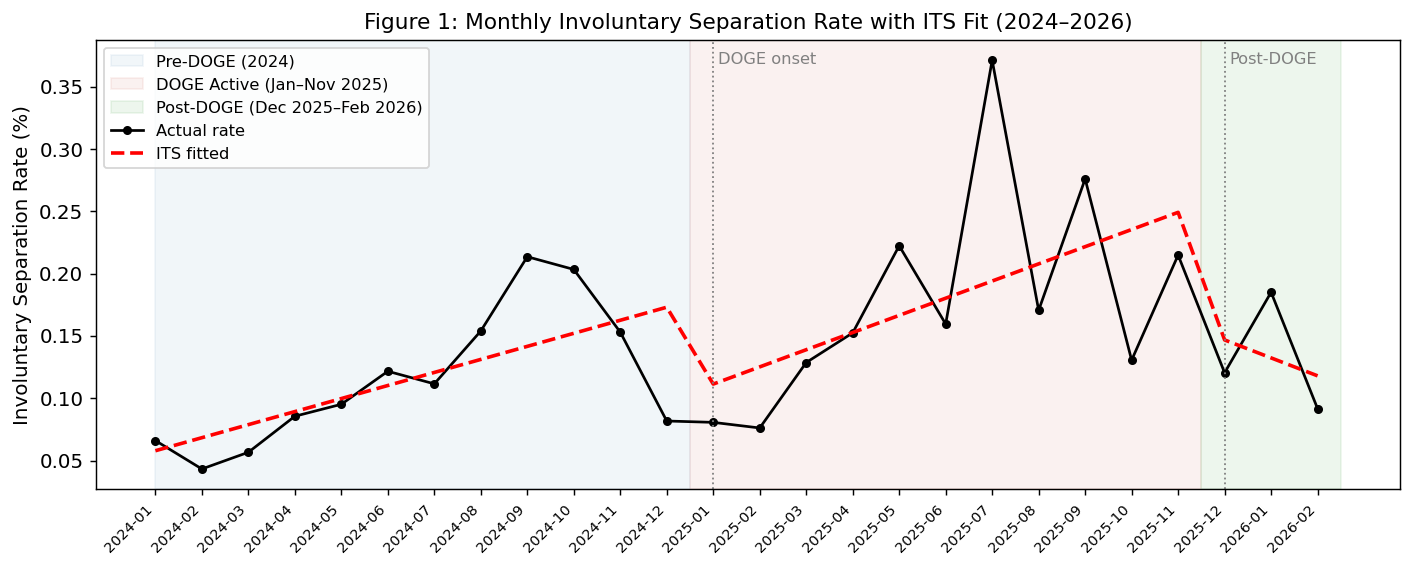

In [157]:
# Figure 1: ITS — Monthly Involuntary Separation Rate with Three-Period Shading
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.axvspan(0, t_doge - 0.5,               alpha=0.07, color='steelblue', label='Pre-DOGE (2024)')
ax.axvspan(t_doge - 0.5, t_post - 0.5,   alpha=0.07, color='#c0392b',  label='DOGE Active (Jan–Nov 2025)')
ax.axvspan(t_post - 0.5, len(its) - 0.5, alpha=0.07, color='green',    label='Post-DOGE (Dec 2025–Feb 2026)')

ax.plot(its['t'], its['inv_rate_pct'], marker='o', color='black', linewidth=1.5, markersize=4, label='Actual rate')
ax.plot(its['t'], model_its.fittedvalues, color='red', linewidth=2, linestyle='--', label='ITS fitted')

for tx, label in [(t_doge, 'DOGE onset'), (t_post, 'Post-DOGE')]:
    ax.axvline(tx, color='gray', linestyle=':', linewidth=1)
    ax.text(tx + 0.1, ax.get_ylim()[1] * 0.95, label, fontsize=9, color='gray')

ax.set_xticks(its['t'])
ax.set_xticklabels(its['ym'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Involuntary Separation Rate (%)')
ax.set_title('Figure 1: Monthly Involuntary Separation Rate with ITS Fit (2024–2026)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT / 'fig1_its.png', bbox_inches='tight')
plt.show()

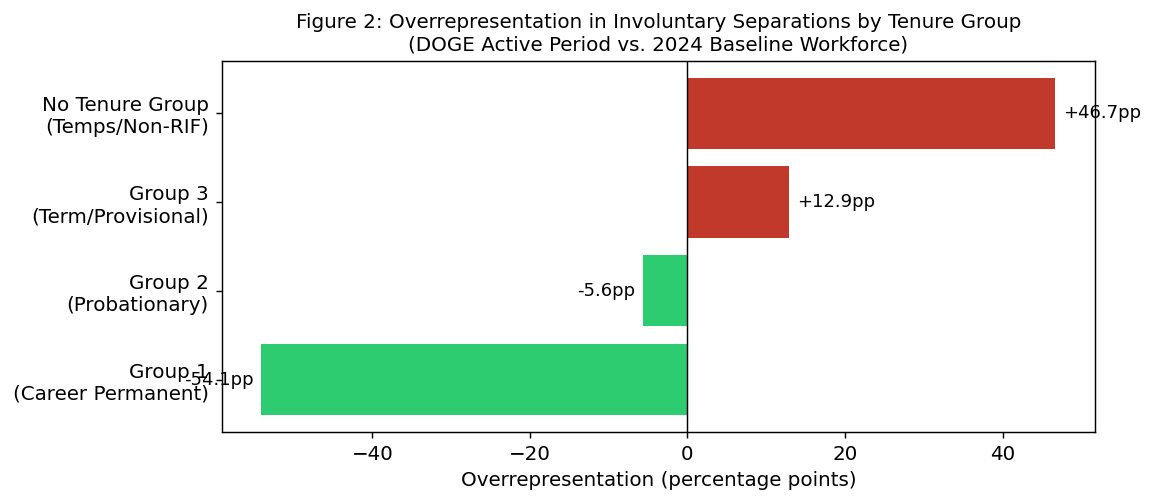

In [158]:
tenure_labels = {
    'NO TENURE GROUP - EMPLOYEES (E.G., TEMPORARIES OR SES) NOT IN TENURE GROUPS 1, 2, OR 3 FOR RIF PURPOSES': 'No Tenure Group\n(Temps/Non-RIF)',
    'TENURE GROUP 3 - TAPER/TERM OR PROVISIONAL OR APPTS W/OUT TIME LIMIT BUT NOT ACTUALLY OR POTENTIALLY PERMANENT': 'Group 3\n(Term/Provisional)',
    'TENURE GROUP 2 - CAREER-CONDITIONAL OR OTHER APPT THAT IS CONDITIONAL OR REQUIRES PROBATIONARY OR TRIAL PERIOD': 'Group 2\n(Probationary)',
    'TENURE GROUP 1 - CAREER OR SERVING AN APPOINTMENT CARRYING NO RESTRICTION OR CONDITION': 'Group 1\n(Career Permanent)',
}
t = tenure_disp.reset_index()
t['label'] = t['tenure'].map(tenure_labels).fillna(t['tenure'])
t = t[t['label'].isin(tenure_labels.values())].sort_values('overrepresentation')
colors = ['#2ecc71' if x < 0 else '#c0392b' for x in t['overrepresentation']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(t['label'], t['overrepresentation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Overrepresentation (percentage points)')
ax.set_title('Figure 2: Overrepresentation in Involuntary Separations by Tenure Group\n(DOGE Active Period vs. 2024 Baseline Workforce)', fontsize=11)
for bar, val in zip(bars, t['overrepresentation']):
    ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}pp', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT / 'fig2_tenure_disparity.png', bbox_inches='tight')
plt.show()

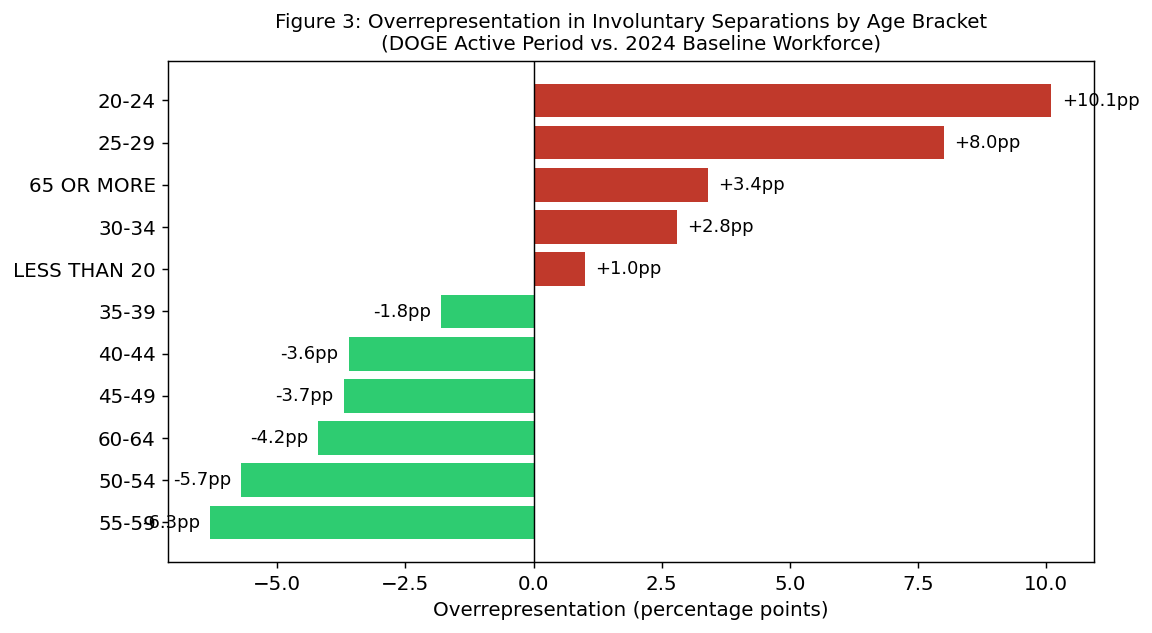

In [159]:
# Figure 3: Age Disparity
a = age_disp.reset_index().sort_values('overrepresentation')
colors = ['#2ecc71' if x < 0 else '#c0392b' for x in a['overrepresentation']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(a['age_bracket'], a['overrepresentation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Overrepresentation (percentage points)')
ax.set_title('Figure 3: Overrepresentation in Involuntary Separations by Age Bracket\n(DOGE Active Period vs. 2024 Baseline Workforce)', fontsize=11)
for bar, val in zip(bars, a['overrepresentation']):
    ax.text(val + (0.2 if val >= 0 else -0.2), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}pp', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT / 'fig3_age_disparity.png', bbox_inches='tight')
plt.show()

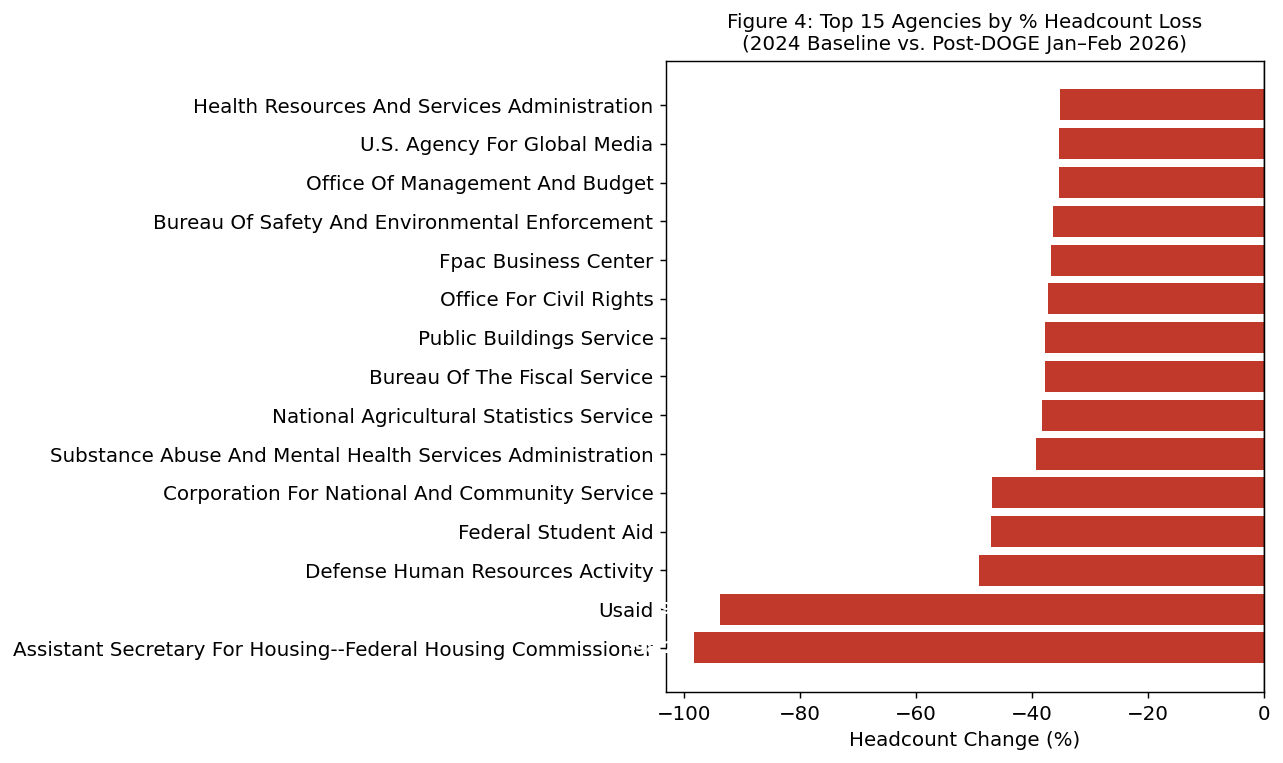

In [160]:
# Figure 4: Top 15 Agencies by % Headcount Loss (2024 baseline vs Post-DOGE)
top15 = (
    collapse[collapse['avg_headcount_2024'] >= 500]
    .sort_values('pct_change')
    .head(15)[['agency_subelement', 'pct_change']]
)
top15['agency_subelement'] = (
    top15['agency_subelement']
    .str.replace('U.S. AGENCY FOR INTERNATIONAL DEVELOPMENT', 'USAID', regex=False)
    .str.title()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15['agency_subelement'], top15['pct_change'], color='#c0392b')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Headcount Change (%)')
ax.set_title('Figure 4: Top 15 Agencies by % Headcount Loss\n(2024 Baseline vs. Post-DOGE Jan–Feb 2026)', fontsize=11)
for bar, val in zip(bars, top15['pct_change']):
    ax.text(val - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT / 'fig4_agency_headcount_loss.png', bbox_inches='tight')
plt.show()

## Key Findings

### 1. Voluntary Separations Are the Dominant Signal — and Significant

Voluntary separations outnumbered involuntary 6-to-1 during DOGE Active (269,260 vs 43,881). The voluntary rate rose from 0.64%/month baseline to 1.11% during DOGE (+73%) and remained elevated at 1.27% post-DOGE.

**Agency-specific trends model (Frisch-Waugh, clustered SEs):**
- Voluntary `doge_active`: **+1.03pp above trend, p = 0.009** ✓
- Voluntary `post_doge`: **+1.48pp above trend, p = 0.007** ✓
- Total attrition `doge_active`: **+0.93pp, p = 0.026** ✓

Kruskal-Wallis across three periods: voluntary H = 6.02, **p = 0.049** (significant); involuntary H = 4.04, p = 0.132 (not significant).

Voluntary exits were elevated above each agency's own projected trajectory during DOGE and did not recover after disbandment — while involuntary rates fell *below* trend post-DOGE (−0.50pp, p = 0.012). This divergence is the clearest evidence of a chilling effect: firings stopped when DOGE ended, but voluntary departures continued.

---

### 2. Involuntary Targeting Was Legally Concentrated — Not Aggregate-Significant

The aggregate involuntary rate rose 0.115% → 0.180%/month, but this difference does not survive panel models controlling for each agency's pre-existing trend (`doge_level` p = 0.184 in Panel ITS). The post-DOGE *fall* is significant (`post_level` p = 0.016). The involuntary increase during DOGE was largely consistent with a trend already underway in 2024; what is statistically anomalous is how sharply rates fell once DOGE ended.

---

### 3. Demographic Targeting Was Systematic — Two Distinct Profiles

All six chi-square tests: p ≈ 0 (n > 13k). The two separation channels hit demographically different populations:

**Involuntary — legally unprotected workers:**
- Tenure: No-tenure-group **+46.7pp**; career permanent **−54.1pp**
- Appointment: Nonpermanent competitive **+21.4pp**; career competitive **−38.8pp**
- Age: 20–24 **+10.1pp**, 25–29 **+8.0pp**; 50–59 **−6pp**
- Work schedule: Intermittent **+17.9pp**; full-time **−20.7pp**
- Education: HS or less **+7.0pp**; bachelor's **−8.6pp**

**Voluntary — chilling effect on older/mid-career workers:**
- Age: 65+ **+7.4pp**, 60–64 **+5.7pp** — consistent with early retirement pressure
- Tenure: Career-conditional **+4.7pp** — workers who chose to leave rather than wait

---

### 4. 22 Agencies Experienced Workforce Collapse (≥20% Headcount Loss)

- **USAID**: −93.8% (4,752 → 294) — effectively eliminated
- **Defense Human Resources Activity**: −49.2%
- **Federal Student Aid**: −47.1%
- **SAMHSA, HRSA, BLM, SBA, NSF**: −30–40%
- **CDC, FDA, IRS, Forest Service, National Park Service**: −21–25%

Total federal headcount fell ~250,000 workers (2.30M → 2.05M, −11%) from the 2024 baseline.

---

### 5. Compositional Shift Appears Permanent

Post-DOGE retention (relative to 2024 baseline):
- Career permanent (tenure group 1): **96.4%** — nearly unaffected
- No-tenure-group: **65.8%**; probationary (tenure group 2): **64.9%**
- Workers 20–24: **70.1%**; workers 45–49: **99.8%**

Young, probationary, and non-permanent workers have not returned in the 3-month post-DOGE observation window, pointing to a durable compositional shift toward an older, more tenured federal workforce.